<a href="https://colab.research.google.com/github/pikey-msc/AprendizMaquina/blob/main/2026-2/feature_engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Ingeniería de variables

In [43]:
!pip install yfinance statsmodels
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from ipywidgets import interact, FloatSlider, IntSlider
from sklearn.model_selection import TimeSeriesSplit

# Descarga de datos reales
ticker = 'BTC-USD'
df = yf.download(ticker, start='2021-01-01')
df.columns = [col[0].lower() if isinstance(col, tuple) else col.lower() for col in df.columns]
print(f'✅ Datos de {ticker} cargados. Registros: {len(df)}')

/tmp/ipython-input-2178482500.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start='2021-01-01')
[*********************100%***********************]  1 of 1 completed

✅ Datos de BTC-USD cargados. Registros: 1867


## 0. 📊 Features Básicos: Inercia y Momentum

| Feature | Fórmula | Lógica Técnica |
| :--- | :---: | :--- |
| **Media Móvil (SMA)** | $\frac{1}{n} \sum_{i=0}^{n-1} x_{t-i}$ | Suaviza el ruido para detectar la tendencia base. |
| **Media Exponencial (EMA)** | $\alpha x_t + (1-\alpha)EMA_{t-1}$ | Da prioridad a los eventos más recientes (inercia). |
| **Lag (Retraso)** | $x_{t-k}$ | Captura la memoria directa o autocorrelación de la serie. |
| **Retorno (ROC)** | $\frac{x_t - x_{t-n}}{x_{t-n}}$ | Mide la velocidad y dirección del cambio en una ventana $n$. |
| **Volatilidad** | $\sqrt{\frac{\sum(x_i - \bar{x})^2}{n-1}}$ | Cuantifica la incertidumbre o el riesgo en el periodo. |



---

### ⚙️ Lógica de Generación de Features

La generación de features se basa en transformar un dato puntual en un **contexto histórico** mediante ventanas móviles.

| Transformación | Base Lógica | Aplicación Práctica |
| :--- | :--- | :--- |
| **Ventanas Móviles** | Agregación de corto vs. largo plazo. | Comparar SMA de 7 días contra 90 días para detectar cruces. |
| **Diferenciación** | Eliminación de tendencia (Estacionariedad). | Convertir niveles de precios en retornos porcentuales. |
| **Ratios** | Normalización de escala. | Dividir el valor actual entre el máximo histórico (Drawdown). |
| **Variables Cíclicas** | Codificación de estacionalidad. | Usar Seno/Coseno para que el modelo entienda ciclos (mes, día). |



---

> **Argumento Central: Señal vs. Ruido**
>
> Un modelo no puede proyectar el futuro basándose solo en el valor actual. Al generar estos features, se expone la **autocorrelación** de los datos. Si la tendencia y el momentum son persistentes, el modelo tiene una base estadística para predecir el siguiente estado del sistema.

In [44]:
## Generar ejemplos

## **1. Memoria y Estacionariedad**
### 📊 **Diferenciación Fraccional**
$$\Delta^d x_t = \sum_{k=0}^\infty \omega_k x_{t-k}$$

In [45]:
def get_weights_fracdiff(d, size):
    w = [1.0]
    for k in range(1, size):
        w_k = -w[-1] * (d - k + 1) / k
        w.append(w_k)
    return np.array(w[::-1]).reshape(-1, 1)

def apply_frac_diff(series, d, window=100):
    w = get_weights_fracdiff(d, window)
    res = [np.dot(w.T, series[i-window:i])[0] for i in range(window, len(series))]
    return pd.Series(res, index=series.index[window:])

@interact(d=FloatSlider(min=0, max=1, step=0.05, value=0.4))
def lab_fracdiff(d):
    fd = apply_frac_diff(df['close'], d)
    p_val = adfuller(fd)[1]
    plt.figure(figsize=(12,4))
    plt.plot(fd, label=f'd={d}', color='blue')
    plt.title(f'ADF p-value: {p_val:.5f}')
    plt.show()

interactive(children=(FloatSlider(value=0.4, description='d', max=1.0, step=0.05), Output()), _dom_classes=('w…

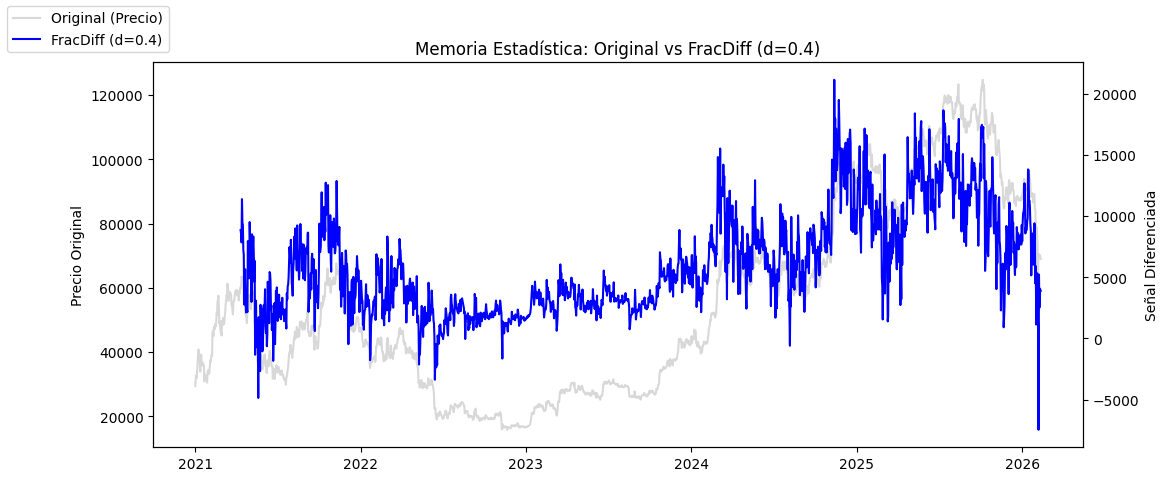

In [46]:
d_val = 0.4
fd = apply_frac_diff(df['close'], d_val)
fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(df['close'], color='gray', alpha=0.3, label='Original (Precio)')
ax1.set_ylabel('Precio Original')
ax2 = ax1.twinx()
ax2.plot(fd, color='blue', label=f'FracDiff (d={d_val})')
ax2.set_ylabel('Señal Diferenciada')
plt.title(f'Memoria Estadística: Original vs FracDiff (d={d_val})')
fig.legend(loc='upper left'); plt.show()

### 📈 **Hurst Exponent**
Determina si la serie tiene memoria persistente ($H > 0.5$) o es ruido.

In [47]:
def hurst(ts):
    lags = range(2, 100)
    tau = [np.sqrt(np.std(np.subtract(ts[lag:], ts[:-lag]))) for lag in lags]
    return np.polyfit(np.log(lags), np.log(tau), 1)[0] * 2

print(f'Hurst Exponent: {hurst(df['close'].values):.4f}')

Hurst Exponent: 0.5186


## **2. Volatilidad de Alta Frecuencia**
### 💥 **Parkinson y Garman-Klass**

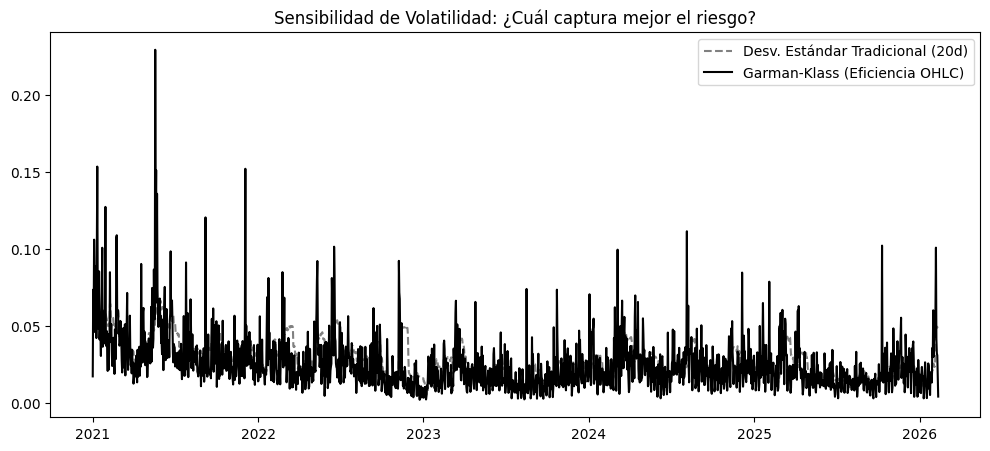

In [48]:
def vol_gk(h, l, o, c):
    return np.sqrt(0.5 * (np.log(h/l))**2 - (2*np.log(2)-1) * (np.log(c/o))**2)

df['std_vol'] = df['close'].pct_change().rolling(20).std()
df['vol_gk'] = vol_gk(df['high'], df['low'], df['open'], df['close'])
# df['vol_gk'].plot(figsize=(12,3), title='Volatilidad GK')

plt.figure(figsize=(12, 5))
plt.plot(df['std_vol'], label='Desv. Estándar Tradicional (20d)', color='gray', linestyle='--')
plt.plot(df['vol_gk'], label='Garman-Klass (Eficiencia OHLC)', color='black')
plt.title('Sensibilidad de Volatilidad: ¿Cuál captura mejor el riesgo?')
plt.legend(); plt.show()

## **4. Microestructura: Dollar Bars y CUSUM**

En finanzas, el tiempo cronológico (minutos, horas) es irrelevante porque la actividad económica no ocurre a un ritmo constante. Para modelos de Machine Learning, necesitamos datos que capturen la **lógica del mercado**, no la del reloj.



### 1. Dollar Bars (Barras de Dólar)

A diferencia de las barras de tiempo, las **Dollar Bars** se generan cada vez que se intercambia un valor acumulado de mercado (Volumen $\times$ Precio) definido por un umbral $m$.

#### ¿Por qué usarlas?
* **Normalidad:** Las barras de tiempo suelen tener distribuciones de retornos con colas pesadas (poco estables). Las Dollar Bars recuperan propiedades de normalidad estadística.
* **Homocedasticidad:** Reducen la varianza no constante, lo que facilita el entrenamiento de los modelos.
* **Muestreo Inteligente:** En periodos de alta volatilidad (donde hay más información), generas más barras; en periodos muertos, generas menos.


### 2. Filtro CUSUM (Cumulative Sum)

El filtro **CUSUM** es una técnica de control de calidad adaptada para detectar cambios estructurales o "eventos" significativos en una serie de tiempo. Se basa en acumular las desviaciones de los retornos respecto a un valor esperado.

#### Mecánica del Filtro
Se definen dos acumuladores, uno para cambios positivos ($S_t^+$) y otro para negativos ($S_t^-$):

$$S_t^+ = \max(0, S_{t-1}^+ + y_t - E[y_t])$$
$$S_t^- = \min(0, S_{t-1}^- + y_t - E[y_t])$$

**Lógica de activación:**
Cuando cualquiera de los dos acumuladores supera un umbral crítico ($h$), se dispara un "evento" y los acumuladores se reinician.

* **Uso:** Sirve para filtrar el ruido y quedarte solo con los puntos donde el precio realmente rompió una tendencia o cambió de régimen.

## 📊 Comparativa de Muestreo

| Tipo de Muestreo | Gatillo de la Barra | Problema Principal |
| :--- | :--- | :--- |
| **Tiempo** | Intervalos fijos (1 min, 1 hora). | Información mal distribuida; mucho ruido. |
| **Volumen** | Cantidad fija de activos transaccionados. | Ignora el impacto del precio en el valor real. |
| **Dollar Bars** | Valor total transaccionado (Fiat). | Es el más cercano a la llegada de información real. |
| **CUSUM** | Desviación acumulada (Varianza). | Solo toma fotos cuando pasa algo relevante. |


> **Resumen**
> El objetivo de usar Dollar Bars y CUSUM es dejar de alimentar al modelo con basura cronológica y pasarle "eventos de información". Si el mercado no se mueve, el modelo no debería estar adivinando; el CUSUM asegura que solo entrenamos con cambios de régimen reales.

Dollar Bars: 1867


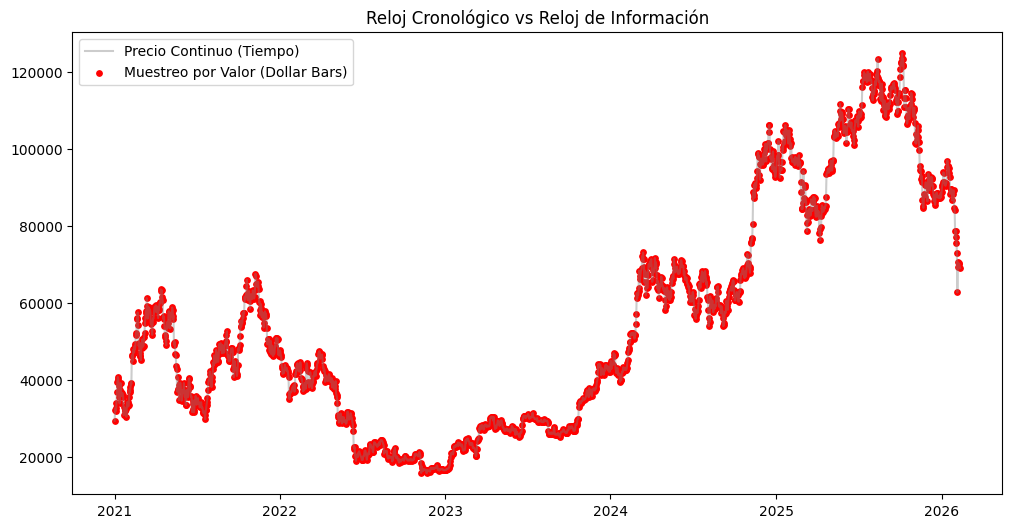

In [49]:
def dollar_bars(df, m):
    df['dv'] = df['close'] * df['volume']
    cv, idx, last = df['dv'].cumsum(), [], 0
    for i, v in enumerate(cv):
        if (v - last) >= m: idx.append(df.index[i]); last = v
    return df.loc[idx]

def cusum_filter(series, threshold):
    t_events, s_pos, s_neg = [], 0, 0
    diff = series.diff()
    for i in diff.index[1:]:
        s_pos, s_neg = max(0, s_pos + diff.loc[i]), min(0, s_neg + diff.loc[i])
        if s_pos > threshold or s_neg < -threshold: t_events.append(i); s_pos, s_neg = 0, 0
    return pd.DatetimeIndex(t_events)

# dbars = dollar_bars(df, 2e9)
print(f'Dollar Bars: {len(dbars)}')

dbars = dollar_bars(df, m=1e9) # Umbral de 1 billón de USD

plt.figure(figsize=(12, 6))
plt.plot(df['close'], color='gray', alpha=0.4, label='Precio Continuo (Tiempo)')
plt.scatter(dbars.index, dbars['close'], color='red', s=15, label='Muestreo por Valor (Dollar Bars)')
plt.title('Reloj Cronológico vs Reloj de Información')
plt.legend(); plt.show()

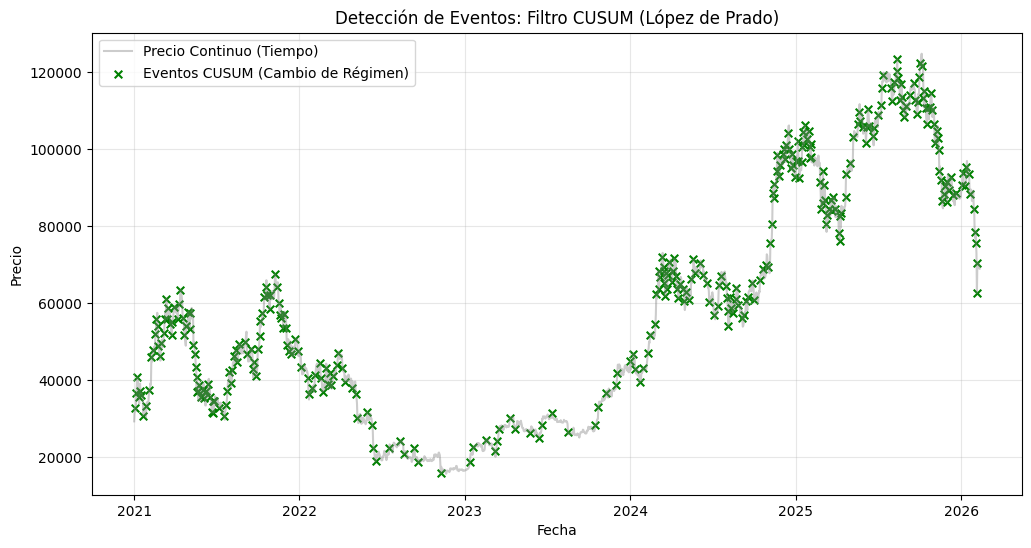

Total de barras de tiempo: 1867
Eventos detectados por CUSUM: 326


In [50]:
# 1. Ejecutamos el filtro sobre los precios o retornos
# El threshold (h) debe ser proporcional a la volatilidad del activo
h_threshold = df['close'].std() * 0.1
cusum_events = cusum_filter(df['close'], threshold=h_threshold)

# 2. Gráfica de comparación
plt.figure(figsize=(12, 6))
plt.plot(df['close'], color='gray', alpha=0.4, label='Precio Continuo (Tiempo)')

# Marcamos los eventos detectados por CUSUM
plt.scatter(cusum_events, df.loc[cusum_events, 'close'],
            color='green', marker='x', s=30, label='Eventos CUSUM (Cambio de Régimen)')

plt.title('Detección de Eventos: Filtro CUSUM (López de Prado)')
plt.xlabel('Fecha')
plt.ylabel('Precio')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Total de barras de tiempo: {len(df)}")
print(f"Eventos detectados por CUSUM: {len(cusum_events)}")

## **. Codificación Cíclica y Validación**

# 🔄 Encoding Cíclico y Validación Temporal

Para que un modelo de Machine Learning entienda el tiempo, no basta con pasarle números ordinales (1, 2, 3...). Necesitamos estructura y rigor en la validación.

---

### 1. Encoding Cíclico (Sin/Cos Transform)

Las variables como el día de la semana o la hora son **cíclicas**. El problema de usar números (0 para lunes, 6 para domingo) es que el modelo cree que el lunes y el domingo están muy lejos, cuando en realidad están pegados.

Al proyectar el tiempo en un círculo usando funciones de seno y coseno, mantenemos la **proximidad temporal**:

* **Seno:** Captura la fase del ciclo.
* **Coseno:** Captura la posición relativa.



**Fórmulas:**
$$x_{sin} = \sin\left(\frac{2\pi \cdot x}{\max(x)}\right)$$
$$x_{cos} = \cos\left(\frac{2\pi \cdot x}{\max(x)}\right)$$

> **¿Por qué hacerlo?** Porque así el modelo entiende que las 23:59 y las 00:01 son prácticamente el mismo momento, y que el domingo y el lunes son días adyacentes.

---

### 2. Validación Walk-Forward (TimeSeriesSplit)

En series de tiempo, **está estrictamente prohibido usar K-Fold Cross Validation tradicional**. Si barajeas (shuffle) los datos, estarías usando información del futuro para predecir el pasado (Data Leakage).

La técnica correcta es el **Walk-Forward Validation** (o Ventana Expandida):

1.  Entrenas con los meses 1-3, pruebas con el mes 4.
2.  Entrenas con los meses 1-4, pruebas con el mes 5.
3.  Entrenas con los meses 1-5, pruebas con el mes 6.



#### Ventajas de TimeSeriesSplit:
* **Cero Leakage:** Siempre respetas el orden cronológico.
* **Robustez:** Evalúas el modelo en diferentes condiciones de mercado (regímenes cambiantes).
* **Realismo:** Simula cómo se usaría el modelo en la vida real: actualizándolo conforme llega nueva información.

---

#### ⚠️ Regla de Oro :
> "Si tu validación no respeta el tiempo, tu precisión es una mentira. Un modelo que predice el ayer con datos de mañana solo sirve para perder dinero de forma eficiente."

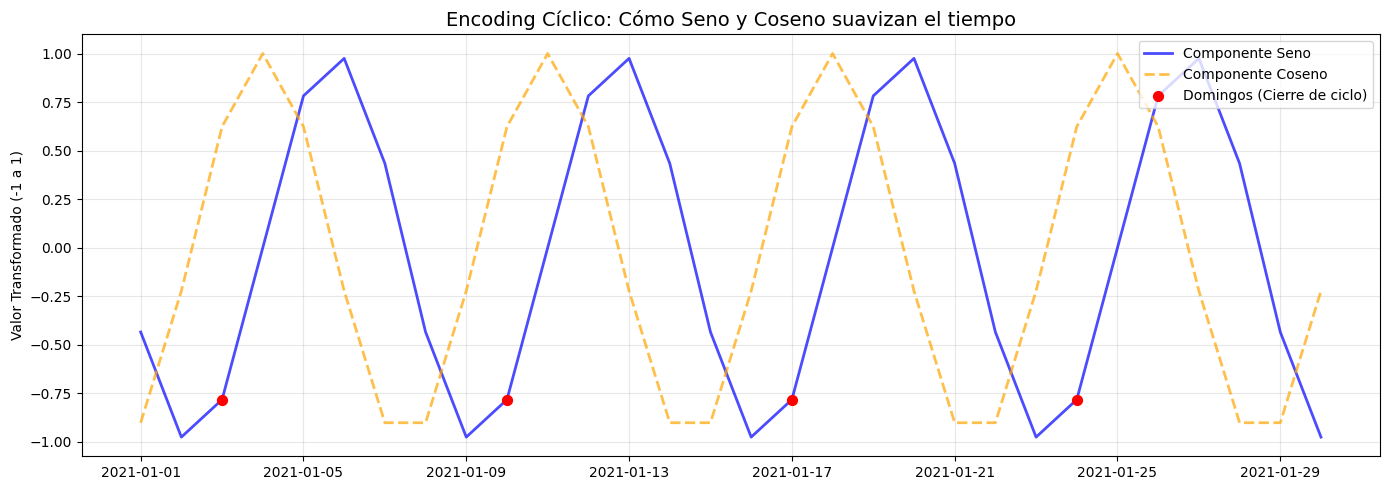

In [54]:
import matplotlib.pyplot as plt

# Tomamos una muestra de 30 días para que se vea claro el patrón
subset = df.iloc[:30]

plt.figure(figsize=(14, 5))

# Graficamos Seno y Coseno
plt.plot(subset.index, subset['day_sin'], label='Componente Seno', color='blue', linewidth=2, alpha=0.7)
plt.plot(subset.index, subset['day_cos'], label='Componente Coseno', color='orange', linewidth=2, linestyle='--', alpha=0.7)

# Ponemos marquitas en los domingos para ubicarnos
domingos = subset[subset.index.dayofweek == 6]
plt.scatter(domingos.index, domingos['day_sin'], color='red', s=50, label='Domingos (Cierre de ciclo)', zorder=5)

plt.title('Encoding Cíclico: Cómo Seno y Coseno suavizan el tiempo', fontsize=14)
plt.ylabel('Valor Transformado (-1 a 1)')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### ¿Qué estamos viendo aquí?

Si usas los números crudos de los días (Lunes=0, ..., Domingo=6), el cambio del Domingo al Lunes siguiente es un salto brusco de 6 a 0. El modelo piensa que pasó algo drástico.

Al usar **Seno (azul)** y **Coseno (naranja)**:

1.  **Suavidad:** El paso del tiempo se convierte en una onda continua. No hay saltos bruscos.
2.  **Ciclo:** Fíjate en los puntos rojos (Domingos). La onda baja y vuelve a subir suavemente para empezar el lunes, justo como en la realidad.
3.  **Coordenada Única:** Cada día tiene una combinación única de valores (Seno, Coseno). El modelo ya no ve un número aislado, ve una posición exacta en la "onda de la semana".

> **En resumen:** Convertimos una escalera rota (0 a 6) en una rampa suave y continua.

Validación Walk-Forward configurada.


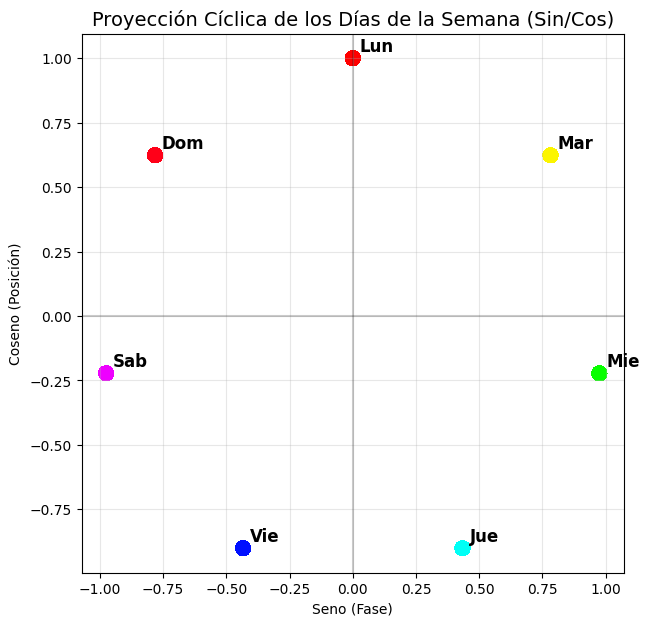

In [52]:
df['day_sin'] = np.sin(2 * np.pi * df.index.dayofweek / 7)
df['day_cos'] = np.cos(2 * np.pi * df.index.dayofweek / 7)

tscv = TimeSeriesSplit(n_splits=5)
for train, test in tscv.split(df):
    pass # Espacio para el modelo del alumno
print('Validación Walk-Forward configurada.')

import matplotlib.pyplot as plt

# Generamos la visualización del círculo
plt.figure(figsize=(7, 7))
plt.scatter(df['day_sin'], df['day_cos'], c=df.index.dayofweek, cmap='hsv', s=100)

# Etiquetas para los días
dias = ['Lun', 'Mar', 'Mie', 'Jue', 'Vie', 'Sab', 'Dom']
for i, txt in enumerate(dias):
    # Buscamos un punto que corresponda a cada día para poner la etiqueta
    sample = df[df.index.dayofweek == i].iloc[0]
    plt.annotate(txt, (sample['day_sin'], sample['day_cos']), xytext=(5,5), textcoords='offset points', fontsize=12, fontweight='bold')

plt.axhline(0, color='black', alpha=0.2)
plt.axvline(0, color='black', alpha=0.2)
plt.title('Proyección Cíclica de los Días de la Semana (Sin/Cos)', fontsize=14)
plt.xlabel('Seno (Fase)')
plt.ylabel('Coseno (Posición)')
plt.grid(True, alpha=0.3)
plt.show()

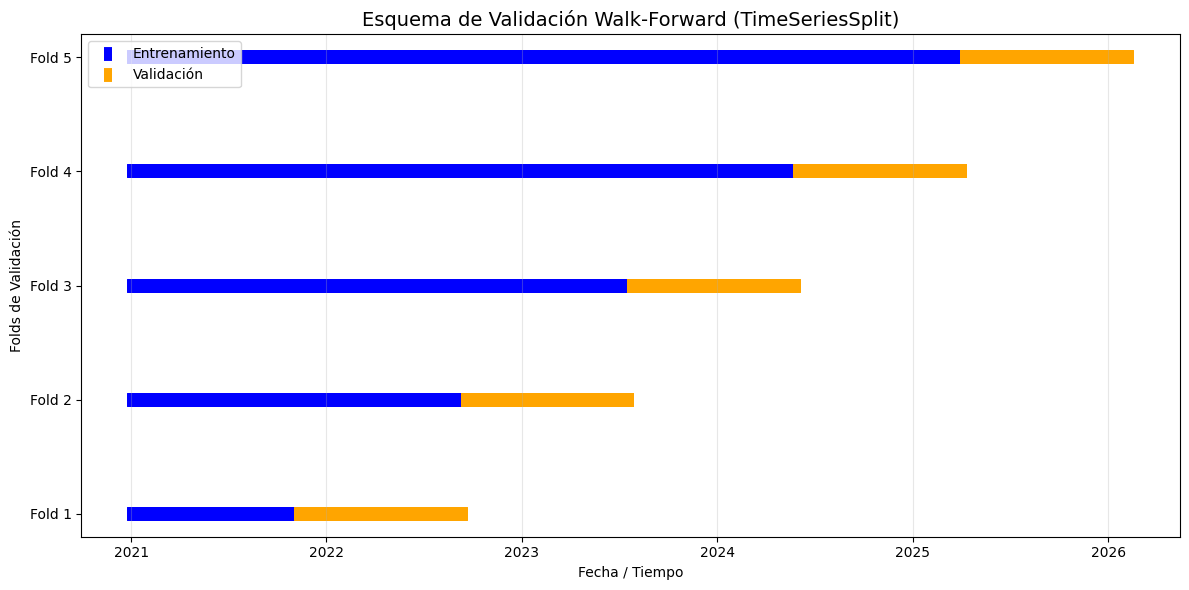

In [53]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)
plt.figure(figsize=(12, 6))

for i, (train_index, test_index) in enumerate(tscv.split(df)):
    # Graficamos los bloques de entrenamiento
    plt.scatter(df.index[train_index], [i] * len(train_index), c='blue', marker='_', lw=10, label='Entrenamiento' if i == 0 else "")
    # Graficamos los bloques de prueba
    plt.scatter(df.index[test_index], [i] * len(test_index), c='orange', marker='_', lw=10, label='Validación' if i == 0 else "")

plt.title('Esquema de Validación Walk-Forward (TimeSeriesSplit)', fontsize=14)
plt.xlabel('Fecha / Tiempo')
plt.ylabel('Folds de Validación')
plt.yticks(range(5), [f'Fold {i+1}' for i in range(5)])
plt.legend(loc='upper left')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### 🔄 ¿Por qué graficamos esto?

**1. El Círculo del Tiempo (Sin/Cos):**
Si dejas los días como 0, 1, 2... 6, el modelo piensa que el Lunes (0) y el Domingo (6) son los puntos más alejados del universo. Al proyectarlos en un círculo, la distancia geométrica entre el Domingo y el Lunes es la misma que entre el Lunes y el Martes. El modelo entiende por fin que el tiempo es un ciclo, no una línea.

**2. La Escalera de Validación (TimeSeriesSplit):**
En finanzas y series de tiempo, el orden de los factores **SÍ** altera el producto. No puedes barajear los datos. Esta gráfica de "escalera" demuestra que siempre estamos parados en el pasado intentando adivinar el futuro, sin ver las cartas de lo que viene después. Si tu esquema de validación no se ve así, estás haciendo trampa (Data Leakage).

## **Features Actuariales y Espaciales**


Aquí tienes el código de las dos secciones listo para que lo copies y pegues en tus celdas de Markdown en Colab.

Markdown
### Distancia Haversine: Geometría para Coordenadas

Esta función sirve para calcular la distancia más corta entre dos puntos en una esfera (como la Tierra). Es necesaria en seguros y logística porque, en distancias largas, la curvatura del planeta hace que una línea recta en un mapa plano falle.

#### La Fórmula

$$d = 2r \arcsin\left(\sqrt{\sin^2\left(\frac{\Delta \phi}{2}\right) + \cos \phi_1 \cos \phi_2 \sin^2\left(\frac{\Delta \lambda}{2}\right)}\right)$$



**Variables:**
* $r$: Radio de la Tierra (~6,371 km).
* $\phi_1, \phi_2$: Latitud de los dos puntos (en radianes).
* $\lambda_1, \lambda_2$: Longitud de los dos puntos (en radianes).
* $\Delta \phi, \Delta \lambda$: Diferencia entre latitudes y longitudes.

#### Comparativa: Euclídea vs. Haversine

| Caso de uso | Distancia Euclídea | Distancia Haversine |
| :--- | :---: | :---: |
| **Poca distancia** (< 5 km) | Funciona bien. | Funciona igual de bien. |
| **Mucha distancia** (> 100 km) | Empieza a tener error. | Se mantiene exacta. |
| **Cerca de los polos** | El error es muy alto. | Sigue funcionando. |

---

Distancia CDMX-GDL: 458.67 km


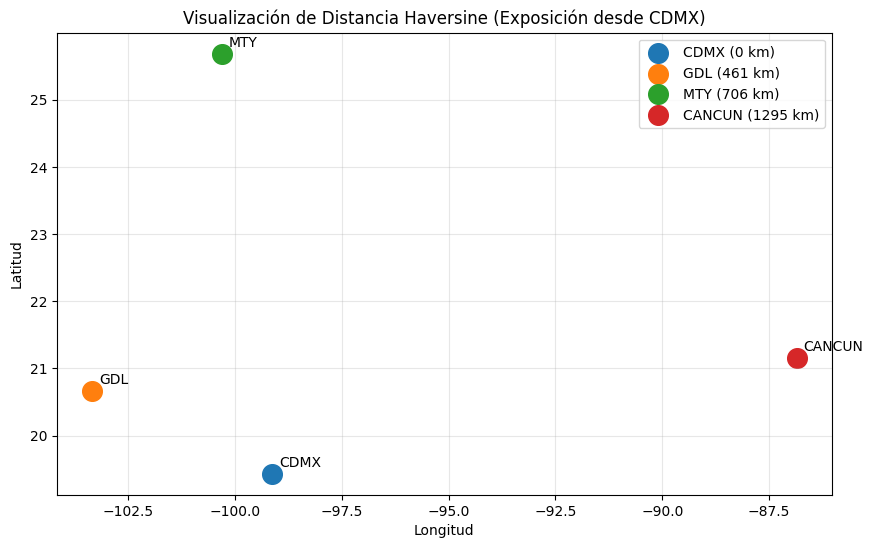

In [40]:

def haversine(lat1, lon1, lat2, lon2):
    r = 6371 # Radio de la Tierra en KM
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi, dlam = np.radians(lat2-lat1), np.radians(lon2-lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlam/2)**2
    return 2 * r * np.arcsin(np.sqrt(a))


print(f'Distancia CDMX-GDL: {haversine(19.4, -99.1, 20.6, -103.3):.2f} km')

# Coordenadas de ejemplo (CDMX, GDL, MTY, CANCUN)
locs = {
    'CDMX': (19.4326, -99.1332),
    'GDL': (20.6597, -103.3496),
    'MTY': (25.6866, -100.3161),
    'CANCUN': (21.1619, -86.8515)
}

# Calculamos distancias respecto a CDMX
cdmx_lat, cdmx_lon = locs['CDMX']
distancias = {k: haversine(cdmx_lat, cdmx_lon, v[0], v[1]) for k, v in locs.items()}

# Gráfica de dispersión geográfica
plt.figure(figsize=(10, 6))
for city, (lat, lon) in locs.items():
    plt.scatter(lon, lat, s=200, label=f"{city} ({distancias[city]:.0f} km)")
    plt.annotate(city, (lon, lat), xytext=(5, 5), textcoords='offset points')

plt.title('Visualización de Distancia Haversine (Exposición desde CDMX)')
plt.xlabel('Longitud'); plt.ylabel('Latitud')
plt.grid(alpha=0.3); plt.legend(); plt.show()

## 🧠 Bayesian Target Encoding: El Arte del "Shrinkage"

En ciencia de datos actuarial, cuando trabajas con variables categóricas de **alta cardinalidad** (como "Modelo de Auto", "Código Postal" o "ID de Cliente"), el **Target Encoding** tradicional es una trampa mortal. Si una categoría tiene muy pocos registros, su promedio será puro ruido, lo que llevará a tu modelo al **overfitting** (sobreajuste).

La solución es el **Bayesian Target Encoding** (también conocido como *Smoothing* o *Credibilidad Actuarial*).


## 1. La Fórmula

Para cada categoría $j$, calculamos un valor codificado $\hat{x}_j$ que pondera la información local contra la información global:

$$\hat{x}_j = \frac{n_j \bar{y}_j + m \mu_{prior}}{n_j + m}$$

### ¿Qué significa cada término?
* $n_j$: El **número de registros** en la categoría $j$ (ej. cuántos Lamborghinis hay en la cartera).
* $\bar{y}_j$: La **media cruda** del target en esa categoría (ej. el costo promedio de choque de esos Lamborghinis).
* $\mu_{prior}$: La **media global** de toda la población (el "ancla" o punto de referencia).
* $m$: El **factor de suavizado** (Credibilidad). Es el número de registros que "exiges" para empezar a confiar en los datos de la categoría.



### 2. El Caso de Uso: Nissan Tsuru vs. Lamborghini

Imagina una aseguradora con una **Media Global ($\mu_{prior}$)** de siniestros de **$5,000**.

### 📊 Comparativa: Media Cruda vs. Media Bayesiana (Credibilidad)

| Modelo de Auto | Casos ($n$) | Media Cruda ($\bar{y}$) | Media Bayesiana ($\hat{x}$) | ¿Qué pasó? |
| :--- | :---: | :---: | :---: | :--- |
| **Nissan Tsuru** | 10,000 |  \$4,800  | \$4,802 | Alta Credibilidad: El valor se mantiene. |
| **VW Jetta** | 5,000 | \$5,500 | \$5,490 | Estabilidad: Ajuste mínimo por volumen. |
| **Lamborghini** | 3 | \$120,000 | \$7,255 | **Shrinkage:** Se jala al promedio por falta de evidencia. |

> **Nota:** El valor de la media bayesiana evita que un siniestro atípico en una muestra pequeña (como los 3 Lambos) destruya la capacidad predictiva del modelo.

### El Efecto del "Shrinkage" (Encogimiento)
Si calibramos un $m = 100$:

* **Tsuru:** Como $10,000$ es mucho mayor que $100$, el resultado final será casi idéntico a $4,800$. **No se mueve.**
* **Lamborghini:** Como $2$ es mucho menor que $100$, la fórmula ignora los $120,000$ y "jala" el valor hacia los $5,000$ globales. El resultado codificado será de aprox. **$7,255**.

##3 3. ¿Por qué esto es importante?

1.  **Estadística de Credibilidad:** Es una implementación de la **Credibilidad de Bühlmann-Straub**. No es un "truco" de programación, es ciencia actuarial pura.
2.  **Manejo de Outliers:** Evita que una categoría pequeña con un valor extremo desvíe tu modelo.
3.  **Generalización:** Al "encoger" los valores hacia la media, el modelo es más robusto y funciona mejor con datos que no ha visto.


### 4. El Parámetro $m$ (El dial de la desconfianza)

* **$m$ pequeño:** Le crees rápido a los datos locales. Riesgo de capturar ruido.
* **$m$ grande:** Eres muy escéptico. Necesitas miles de datos para dejar de usar la media global.

> **Regla de oro:** El valor de $m$ se **calibra** mediante validación cruzada. Es el punto donde el error de tu modelo (RMSE o MAE) es más bajo.


### Conclusión :
> *"Si tu categoría no tiene suficiente N, tu promedio es una mentira. El Bayesian Encoding es la verdad estadística aplicada al riesgo. No dejes que el ruido maneje tu modelo."*

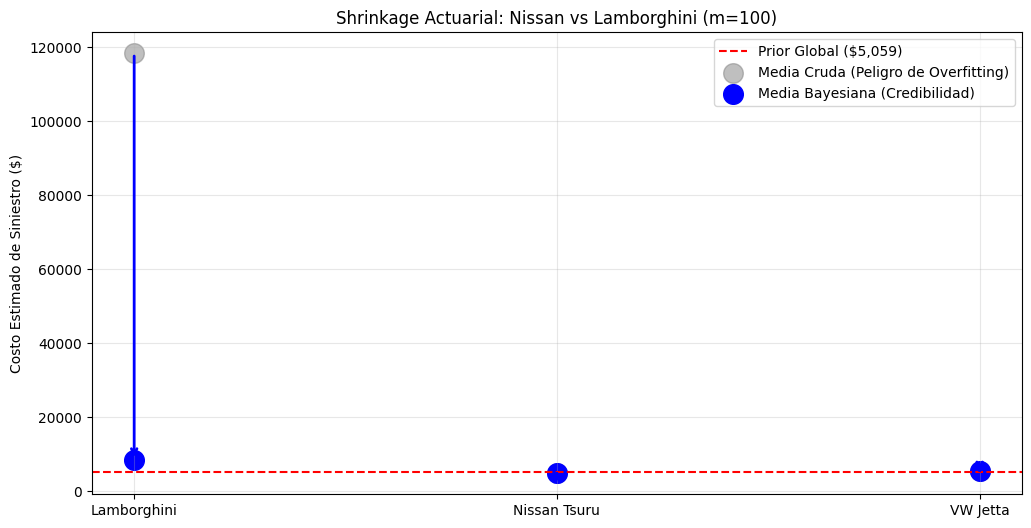

Media Global (Prior): $5,058.79

                  N    Media Cruda  Media Bayesiana
modelo                                             
Lamborghini       3  118333.333333      8358.044131
VW Jetta       5000    5512.663602      5503.764030
Nissan Tsuru  10000    4797.864017      4800.447397


In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. GENERACIÓN DE DATOS "DE LA CALLE"
np.random.seed(42)

# Cartera: 10,000 Tsurus, 5,000 Jettas y 3 Lamborghinis
modelos = (['Nissan Tsuru'] * 10000) + (['VW Jetta'] * 5000) + (['Lamborghini'] * 3)

# Siniestros base (Promedio Global alrededor de $5,000)
# Tsuru: Barato pero constante | Jetta: Medio | Lambo: Accidente catastrófico (ruido)
siniestros = np.concatenate([
    np.random.normal(4800, 1000, 10000), # Tsuru
    np.random.normal(5500, 1200, 5000),  # Jetta
    [150000, 200000, 5000]               # Lamborghini (2 choques épicos y uno que no ha chocado)
])

df = pd.DataFrame({'modelo': modelos, 'siniestro': siniestros})

# 2. FUNCIÓN DE TARGET ENCODING BAYESIANO
def bayesian_encode(df, cat_col, target_col, m=100):
    global_mean = df[target_col].mean()
    agg = df.groupby(cat_col)[target_col].agg(['count', 'mean'])

    # La fórmula perrona:
    # (n * media_local + m * media_global) / (n + m)
    counts = agg['count']
    means = agg['mean']
    smooth = (counts * means + m * global_mean) / (counts + m)

    return smooth, means, global_mean

# Aplicamos con un factor m=100 (Credibilidad moderada)
m_factor = 100
smooth_vals, raw_means, global_avg = bayesian_encode(df, 'modelo', 'siniestro', m=m_factor)

# 3. GRÁFICA DE LA VERDAD
plt.figure(figsize=(12, 6))
plt.axhline(global_avg, color='red', linestyle='--', label=f'Prior Global (${global_avg:,.0f})')

# Puntos de datos
plt.scatter(raw_means.index, raw_means, color='gray', s=200, alpha=0.5, label='Media Cruda (Peligro de Overfitting)')
plt.scatter(smooth_vals.index, smooth_vals, color='blue', s=200, label='Media Bayesiana (Credibilidad)')

# Flechas de Shrinkage
for i, modelo in enumerate(raw_means.index):
    plt.annotate('', xy=(i, smooth_vals[modelo]), xytext=(i, raw_means[modelo]),
                 arrowprops=dict(arrowstyle='->', color='blue', lw=2))

plt.title(f'Shrinkage Actuarial: Nissan vs Lamborghini (m={m_factor})')
plt.ylabel('Costo Estimado de Siniestro ($)')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# --- REPORTE FINAL ---
print(f"Media Global (Prior): ${global_avg:,.2f}\n")
res = pd.DataFrame({'N': df.groupby('modelo').size(), 'Media Cruda': raw_means, 'Media Bayesiana': smooth_vals})
print(res.sort_values('N'))